In [1]:
import matplotlib.pyplot as plt

def read_depths(fname):
    """return {event_name: depth_in_m} from a pyrocko .pf catalogue"""
    depths, name = {}, None
    for line in open(fname):
        if line.startswith('name'):
            name = line.split('=')[1].strip()
        elif line.startswith('depth'):
            depths[name] = float(line.split('=')[1])
    return depths

vt = read_depths('../CAT/catalogue_flegrei_MT_VT.pf')
vlp = read_depths('../CAT/catalogue_flegrei_composite_MT_LF_std_reloc_best.pf')

names = [n for n in vt if n in vlp]
x = [vt[n] / 1000. for n in names]
y = [vlp[n] / 1000. for n in names]
print(len(names), 'common events')

19 common events


In [5]:
import numpy as np
vlp_mean_depth= np.mean(y)
vlp_std_depth= np.std(y)
print('VLP mean depth: %.4f km +- %.4f km' % (vlp_mean_depth, vlp_std_depth))

VLP mean depth: 4.1389 km +- 0.2845 km


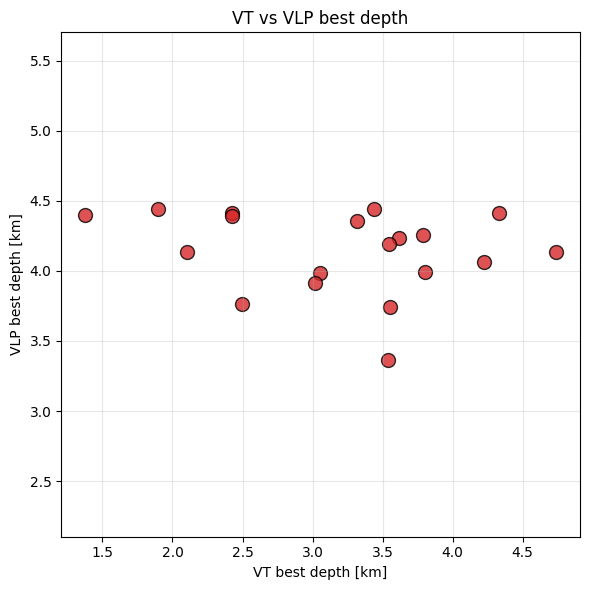

In [2]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x, y, c='tab:red', alpha=0.8, s=100, edgecolors='k', label='events')

ax.set_xlabel('VT best depth [km]')
ax.set_ylabel('VLP best depth [km]')
ax.set_title('VT vs VLP best depth')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.axis('equal')
plt.show()